In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Set visualization styles
sns.set_theme(style="whitegrid")

# 1. Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='Target')

print("--- Dataset Snapshot ---")
print(f"Dataset Dimensions: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target Distribution: {np.bincount(y)[0]} Malignant (0), {np.bincount(y)[1]} Benign (1)")

# Check for missing values
print("\n--- Missing Values Check ---")
print(f"Total Missing Values: {X.isnull().sum().sum()}")

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing and stratification completed successfully.")

--- Dataset Snapshot ---
Dataset Dimensions: 569 samples, 30 features
Target Distribution: 212 Malignant (0), 357 Benign (1)

--- Missing Values Check ---
Total Missing Values: 0

Preprocessing and stratification completed successfully.


In [2]:
# Initialize dictionaries to store trained models and evaluation metrics
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', C=1.0, random_state=42),
    "k-Nearest Neighbors (k-NN)": KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("--- Training and Evaluating Classifiers ---")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Save the evaluations
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

print("\nAll models trained and evaluated successfully.")

--- Training and Evaluating Classifiers ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Support Vector Machine (SVM)...
Training k-Nearest Neighbors (k-NN)...

All models trained and evaluated successfully.


--- Classifier Performance Comparison Table ---
                              Accuracy  Precision  Recall  F1-Score
Logistic Regression             0.9825     0.9861  0.9861    0.9861
Decision Tree                   0.9211     0.9565  0.9167    0.9362
Random Forest                   0.9561     0.9589  0.9722    0.9655
Support Vector Machine (SVM)    0.9825     0.9861  0.9861    0.9861
k-Nearest Neighbors (k-NN)      0.9561     0.9589  0.9722    0.9655


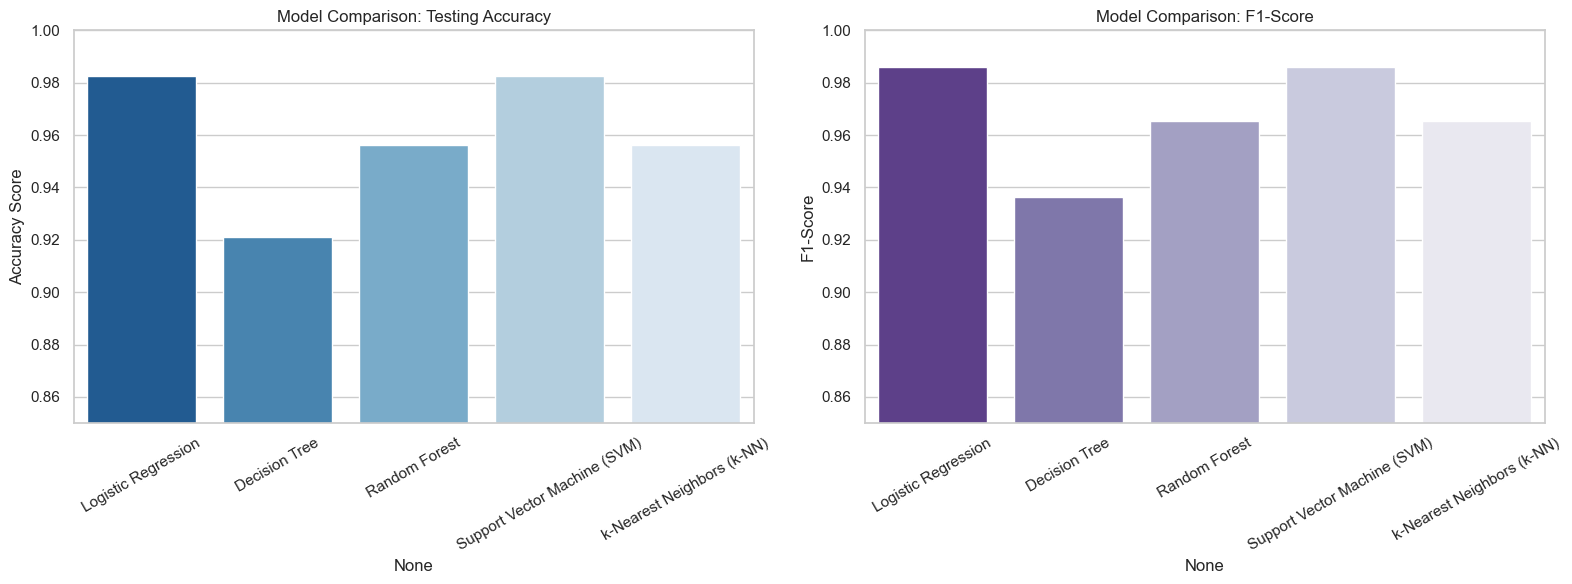

In [3]:
# Convert evaluations dictionary into a DataFrame for visual reporting
results_df = pd.DataFrame(results).T
print("--- Classifier Performance Comparison Table ---")
print(results_df.round(4))

# Visualization: Compare Accuracy and F1-Score side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
sns.barplot(x=results_df.index, y=results_df['Accuracy'], ax=axes[0], palette='Blues_r', hue=results_df.index, legend=False)
axes[0].set_title('Model Comparison: Testing Accuracy')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(0.85, 1.0)  # Zoom in to see performance differences clearly
axes[0].tick_params(axis='x', rotation=30)

# Plot F1-Score
sns.barplot(x=results_df.index, y=results_df['F1-Score'], ax=axes[1], palette='Purples_r', hue=results_df.index, legend=False)
axes[1].set_title('Model Comparison: F1-Score')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.85, 1.0)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()